In [1]:
import pandas as pd
import numpy as np

# ==============================
# Load 55 correlation features
# ==============================

X_train = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/X_train_correlation_55.parquet"
)

X_test = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/X_test_correlation_55.parquet"
)

# Labels
y_train = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/y_train_selected.parquet"
)["Label"]

y_test = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/y_test_selected.parquet"
)["Label"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("Number of features:", X_train.shape[1])
print("Number of classes:", y_train.nunique())

X_train: (1785379, 55)
X_test : (446345, 55)
y_train: (1785379,)
y_test : (446345,)
Number of features: 55
Number of classes: 15


In [2]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(y_train.nunique())
)

print("y_test_bin shape:", y_test_bin.shape)

y_test_bin shape: (446345, 15)


# 1. Random Forest 

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf_55 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

print("Training Random Forest...")

rf_55.fit(X_train, y_train)

print("Random Forest training completed.")

y_pred_rf_55 = rf_55.predict(X_test)
y_prob_rf_55 = rf_55.predict_proba(X_test)

print("Prediction shape:", y_pred_rf_55.shape)

Training Random Forest...
Random Forest training completed.
Prediction shape: (446345,)


# 2. LightGBM

In [4]:
import os
import pandas as pd

# Find the saved 55-feature files
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if "correlation_55" in file:
            print(os.path.join(root, file))

/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/X_test_correlation_55.parquet
/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/correlation_55_features.csv
/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/X_train_correlation_55.parquet


In [5]:
X_train_corr = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/X_train_correlation_55.parquet"
)

X_test_corr = pd.read_parquet(
    "/kaggle/input/notebooks/nadianoumee/ids-2017-feature-selection/X_test_correlation_55.parquet"
)

print("X_train_corr:", X_train_corr.shape)
print("X_test_corr:", X_test_corr.shape)

X_train_corr: (1785379, 55)
X_test_corr: (446345, 55)


In [6]:
from lightgbm import LGBMClassifier

lgbm_55 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

print("Training LightGBM on 55 correlation-selected features...")

lgbm_55.fit(X_train_corr, y_train)

print("LightGBM 55-feature training completed.")

y_pred_lgbm_55 = lgbm_55.predict(X_test_corr)
y_prob_lgbm_55 = lgbm_55.predict_proba(X_test_corr)

print("Prediction shape:", y_pred_lgbm_55.shape)

Training LightGBM on 55 correlation-selected features...
LightGBM 55-feature training completed.
Prediction shape: (446345,)


# 3. CatBoost

In [7]:
from catboost import CatBoostClassifier

cat_55 = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    random_seed=42,
    verbose=0
)

print("Training CatBoost on 55 correlation-selected features...")

cat_55.fit(X_train_corr, y_train)

print("CatBoost 55-feature training completed.")

y_pred_cat_55 = cat_55.predict(X_test_corr)
y_prob_cat_55 = cat_55.predict_proba(X_test_corr)

print("Prediction shape:", y_pred_cat_55.shape)

Training CatBoost on 55 correlation-selected features...
CatBoost 55-feature training completed.
Prediction shape: (446345, 1)


# 4. XGBooost

In [8]:
from xgboost import XGBClassifier

xgb_55 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=y_train.nunique(),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

print("Training XGBoost on 55 correlation-selected features...")

xgb_55.fit(X_train_corr, y_train)

print("XGBoost 55-feature training completed.")

y_pred_xgb_55 = xgb_55.predict(X_test_corr)
y_prob_xgb_55 = xgb_55.predict_proba(X_test_corr)

print("Prediction shape:", y_pred_xgb_55.shape)

Training XGBoost on 55 correlation-selected features...
XGBoost 55-feature training completed.
Prediction shape: (446345,)


In [9]:
# Save 55-feature predictions for XGBoost

xgb_55_predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_xgb_55
})

xgb_55_predictions.to_csv(
    "/kaggle/working/xgb_55_predictions.csv",
    index=False
)

print("XGBoost 55-feature predictions saved.")
print(xgb_55_predictions.head())

XGBoost 55-feature predictions saved.
   Actual  Predicted
0       0          0
1       0          0
2       4          4
3       0          0
4       0          0


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)
import pandas as pd

# Function to calculate all metrics
def calculate_metrics(y_true, y_pred, y_prob, y_true_bin):

    return {
        "Accuracy": accuracy_score(
            y_true, y_pred
        ),

        "Weighted Precision": precision_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ),

        "Weighted Recall": recall_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ),

        "Weighted F1": f1_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ),

        "Macro Precision": precision_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),

        "Macro Recall": recall_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),

        "MCC": matthews_corrcoef(
            y_true, y_pred
        ),

        "AUC": roc_auc_score(
            y_true_bin,
            y_prob,
            average="weighted"
        )
    }

# Calculate metrics for all 4 models

rf_metrics_55 = calculate_metrics(
    y_test, y_pred_rf_55, y_prob_rf_55, y_test_bin
)

lgbm_metrics_55 = calculate_metrics(
    y_test, y_pred_lgbm_55, y_prob_lgbm_55, y_test_bin
)

cat_metrics_55 = calculate_metrics(
    y_test, y_pred_cat_55, y_prob_cat_55, y_test_bin
)

xgb_metrics_55 = calculate_metrics(
    y_test, y_pred_xgb_55, y_prob_xgb_55, y_test_bin
)


# Create comparison table

results_55 = pd.DataFrame([
    {"Model": "Random Forest", **rf_metrics_55},
    {"Model": "LightGBM", **lgbm_metrics_55},
    {"Model": "CatBoost", **cat_metrics_55},
    {"Model": "XGBoost", **xgb_metrics_55}
])

print("55-Feature Model Results:")
display(results_55)

55-Feature Model Results:


,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1,MCC,AUC
0,Random Forest,0.998488,0.998430,0.998488,0.998445,0.925712,0.831095,0.857991,0.994384,0.999874
1,LightGBM,0.911239,0.906387,0.911239,0.897873,0.238860,0.154513,0.181279,0.619659,0.742533
2,CatBoost,0.998035,0.998091,0.998035,0.997856,0.902742,0.723109,0.747840,0.992695,0.999933
3,XGBoost,0.998524,0.998472,0.998524,0.998381,0.945811,0.822900,0.848455,0.994514,0.999965


In [11]:
results_55.to_csv(
    "/kaggle/working/55_feature_model_results.csv",
    index=False
)

print("55-feature model results saved successfully.")

55-feature model results saved successfully.


In [12]:
# Convert 55-feature results into vertical format

results_55_vertical = results_55.melt(
    id_vars=["Model"],
    var_name="Metric",
    value_name="Value"
)

display(results_55_vertical)

,Model,Metric,Value
0,Random Forest,Accuracy,0.998488
1,LightGBM,Accuracy,0.911239
2,CatBoost,Accuracy,0.998035
3,XGBoost,Accuracy,0.998524
4,Random Forest,Weighted Precision,0.998430
5,LightGBM,Weighted Precision,0.906387
6,CatBoost,Weighted Precision,0.998091
7,XGBoost,Weighted Precision,0.998472
8,Random Forest,Weighted Recall,0.998488
9,LightGBM,Weighted Recall,0.911239


In [13]:
results_55_vertical.to_csv(
    "/kaggle/working/55_feature_model_results_vertical.csv",
    index=False
)

print("55-feature vertical results saved successfully.")

55-feature vertical results saved successfully.


In [14]:
# ============================================
# SHAP FEATURE RANKING - 55 FEATURES
# ============================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Use a representative sample because the full dataset is very large
shap_sample_size = 10000

if len(X_train_corr) > shap_sample_size:
    X_shap_55 = X_train_corr.sample(
        n=shap_sample_size,
        random_state=42
    )
else:
    X_shap_55 = X_train_corr.copy()

print("SHAP sample shape:", X_shap_55.shape)

# Create SHAP explainer for the trained XGBoost model
explainer_55 = shap.TreeExplainer(xgb_55)

shap_values_55 = explainer_55.shap_values(X_shap_55)

print("SHAP calculation completed.")

SHAP sample shape: (10000, 55)
SHAP calculation completed.


In [15]:
# ============================================
# CALCULATE 55-FEATURE SHAP RANKING
# ============================================

# Handle multiclass SHAP output
if isinstance(shap_values_55, list):
    shap_abs_mean_55 = np.mean(
        [
            np.abs(values).mean(axis=0)
            for values in shap_values_55
        ],
        axis=0
    )
else:
    shap_array = np.asarray(shap_values_55)

    if shap_array.ndim == 3:
        # samples × features × classes
        shap_abs_mean_55 = np.abs(
            shap_array
        ).mean(axis=(0, 2))
    else:
        shap_abs_mean_55 = np.abs(
            shap_array
        ).mean(axis=0)

shap_ranking_55 = pd.DataFrame({
    "Feature": X_shap_55.columns,
    "Mean_Absolute_SHAP": shap_abs_mean_55
})

shap_ranking_55 = shap_ranking_55.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

shap_ranking_55["Rank"] = (
    np.arange(len(shap_ranking_55)) + 1
)

# Put Rank first
shap_ranking_55 = shap_ranking_55[
    ["Rank", "Feature", "Mean_Absolute_SHAP"]
]

display(shap_ranking_55)

print("Number of ranked features:", len(shap_ranking_55))

,Rank,Feature,Mean_Absolute_SHAP
0,1,Init Fwd Win Bytes,0.283406
1,2,Init Bwd Win Bytes,0.271730
2,3,Packet Length Mean,0.218243
3,4,Fwd Packet Length Max,0.203931
4,5,Fwd Seg Size Min,0.187907
5,6,Bwd Packet Length Max,0.152187
6,7,Packet Length Variance,0.123923
7,8,Fwd IAT Min,0.122591
8,9,Fwd Packet Length Mean,0.120394
9,10,Fwd Packets Length Total,0.101408


Number of ranked features: 55


In [16]:
# ============================================
# SAVE 55-FEATURE SHAP RANKING
# ============================================

output_dir = "/kaggle/working/final_outputs"
os.makedirs(output_dir, exist_ok=True)

shap_ranking_55.to_csv(
    f"{output_dir}/shap_feature_ranking_55.csv",
    index=False
)

print(
    "Saved:",
    f"{output_dir}/shap_feature_ranking_55.csv"
)

Saved: /kaggle/working/final_outputs/shap_feature_ranking_55.csv


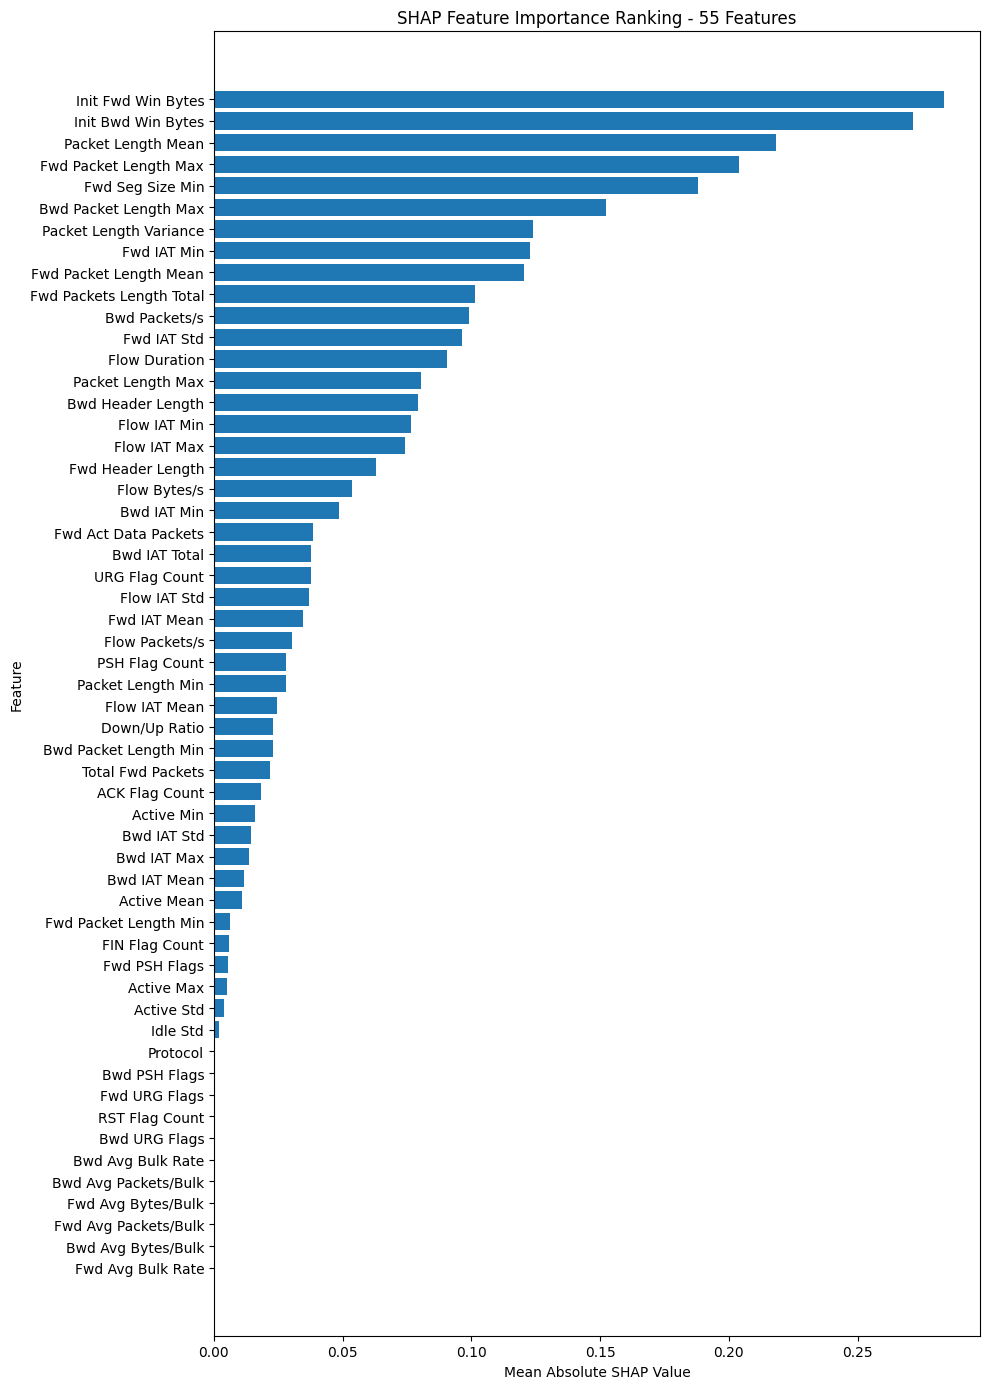

55-feature SHAP importance graph saved.


In [17]:
# ============================================
# SHAP FEATURE IMPORTANCE - 55 FEATURES
# ============================================

plt.figure(figsize=(10, 14))

plt.barh(
    shap_ranking_55["Feature"],
    shap_ranking_55["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title(
    "SHAP Feature Importance Ranking - 55 Features"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    f"{output_dir}/shap_feature_importance_55.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

print("55-feature SHAP importance graph saved.")